In [20]:
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import albumentations as A
from dotenv import load_dotenv
from torch.utils.data import Dataset
import torch


In [21]:
load_dotenv()
np.random.seed(0)

In [22]:
# Model Configuration
TARGET_HEIGHT = 640  # YOLO works best with 640x640 (will be set automatically)
TARGET_WIDTH = 640  # YOLO typically uses square images
# Dataset Configuration
FINETUNE_DS_DIR = os.getenv("FINETUNE_DIR")
DATASET_IMAGES_DIR_NAME = "app_media_storage"
DATASET_IMAGES_DIR = os.path.join(FINETUNE_DS_DIR, DATASET_IMAGES_DIR_NAME)
ANNOTATIONS_PATH = os.path.join(FINETUNE_DS_DIR, "picture_bb_annotations.csv")
IMG_METADATA_PATH = os.path.join(FINETUNE_DS_DIR, "media.csv")
DATASET_VERSION = "2025-30-09"
# Experiment logging
BEST_MODEL_PATH = os.getenv("BEST_MODEL_PATH")
MLFLOW_URI = os.getenv("MLFLOW_URI")
MLFLOW_EXPERIMENT_NAME = f"Fetal_Structures_yolo_{TARGET_HEIGHT}x{TARGET_WIDTH}_finetuned_solimed"
MLFLOW_USER = os.getenv("MLFLOW_USER")
MODEL_NAME = f"fetal_structures_yolo_{TARGET_HEIGHT}x{TARGET_WIDTH}_finetuned_solimed_{DATASET_VERSION}"
# Training parameters
K_FOLDS = 1
BATCH_SIZE = 32
NUM_EPOCHS = 1000
LEARNING_RATE = 1e-2
WEIGHT_DECAY = 5e-4
# EARLY_STOPPING_PATIENCE = 100
EARLY_STOPPING_PATIENCE = 20

In [23]:
# Show image metadata for frames
img_metadata_df = pd.read_csv(IMG_METADATA_PATH)
img_metadata_df = img_metadata_df[img_metadata_df['media_type'] == 'frame']
img_metadata_df

,id,study_id,filename,file_path,file_size,mime_type,media_type,upload_status,is_active,created_at,updated_at
4,b38b420d-e4e1-4bd8-abff-3efdf16282bb,f0a7d10c-dfd5-45e4-a5f7-05fae9a8175a,frame_2538f00b-a0a4-4e42-ad1f-fd12db68d679_2.3...,7fd3ef91-193a-4170-bb65-21c392c5e0f4,85611,image/jpeg,frame,uploaded,True,2025-09-29 21:47:42.084 -0300,2025-09-29 21:47:42.084 -0300
5,6ce7fe0e-28ac-40bc-93ed-101adffc4940,f0a7d10c-dfd5-45e4-a5f7-05fae9a8175a,frame_2538f00b-a0a4-4e42-ad1f-fd12db68d679_2.3...,1e5727e8-b7bd-4c90-a472-7515aacf1395,85611,image/jpeg,frame,uploaded,True,2025-09-29 21:48:06.884 -0300,2025-09-29 21:48:06.884 -0300
6,59d1957d-54e1-49ee-b63f-fd31eb4bdaf5,f0a7d10c-dfd5-45e4-a5f7-05fae9a8175a,frame_2538f00b-a0a4-4e42-ad1f-fd12db68d679_1.1...,5a2d975e-f0c2-4d9e-aa32-0314642cd81f,83346,image/jpeg,frame,uploaded,True,2025-09-29 21:48:55.011 -0300,2025-09-29 21:48:55.011 -0300
9,ce2e9778-bc1e-41d3-a50f-ca956d8ba7e6,0bac7e49-2b9a-4c09-9397-6bff555c77f9,frame_103846b8-0411-4203-8ad9-896a7dc5cd1f_1.0...,33477ed2-4325-4562-b30b-619c8c810359,81444,image/jpeg,frame,uploaded,True,2025-09-30 19:15:49.891 -0300,2025-09-30 19:15:49.891 -0300
10,0d83b773-8eda-4cab-bb66-49b43b7dd1c3,0bac7e49-2b9a-4c09-9397-6bff555c77f9,frame_103846b8-0411-4203-8ad9-896a7dc5cd1f_2.3...,2c367976-fce6-46ea-b06a-052b39299d60,85611,image/jpeg,frame,uploaded,True,2025-09-30 19:16:00.562 -0300,2025-09-30 19:16:00.562 -0300
...,...,...,...,...,...,...,...,...,...,...,...
93,30e518d8-3b39-4e4f-a802-a22b29e62f33,0bac7e49-2b9a-4c09-9397-6bff555c77f9,frame_7d39bd17-db94-43f6-8f0e-44064b409f14_0.2...,2e1e6068-265f-4a94-862b-859889d06f8c,81004,image/jpeg,frame,uploaded,True,2025-09-30 21:09:26.762 -0300,2025-09-30 21:09:26.762 -0300
94,dc81867e-67b5-4cfe-9f3b-cbc17fbb3132,0bac7e49-2b9a-4c09-9397-6bff555c77f9,frame_a244dfb4-42ad-47b5-b3fe-6b6d38f770f4_0.4...,0e00dd97-4203-4755-8229-efb20976ac7c,83078,image/jpeg,frame,uploaded,True,2025-09-30 21:10:52.027 -0300,2025-09-30 21:10:52.027 -0300
95,38bd2c0f-7c8f-40ea-a5c1-83ea9d6251a5,0bac7e49-2b9a-4c09-9397-6bff555c77f9,frame_a244dfb4-42ad-47b5-b3fe-6b6d38f770f4_0.5...,abce4779-6658-49b8-a2cb-30bd50427f4d,83481,image/jpeg,frame,uploaded,True,2025-09-30 21:12:00.919 -0300,2025-09-30 21:12:00.919 -0300
96,98d6c4dd-3cb4-4468-bc55-9faa1e12e3a0,0bac7e49-2b9a-4c09-9397-6bff555c77f9,frame_a244dfb4-42ad-47b5-b3fe-6b6d38f770f4_0.8...,5821d973-cecd-41e9-8937-aad738e5ac6e,83237,image/jpeg,frame,uploaded,True,2025-09-30 21:12:35.173 -0300,2025-09-30 21:12:35.173 -0300


In [24]:
# Load and preprocess annotations
annotations_df = pd.read_csv(ANNOTATIONS_PATH)
annotations_df = annotations_df[annotations_df['bb_class'].isin(['NB', 'NT'])]
annotations_df = annotations_df[annotations_df['media_type'] == 'frame']

# Merge with media metadata to get file paths
annotations_df = annotations_df.merge(
    img_metadata_df[['id', 'file_path', 'filename']],
    left_on='media_id',
    right_on='id',
    suffixes=('', '_media')
)

# Convert x_min, y_min, width, height, to integers
annotations_df['x_min'] = annotations_df['x_min'].astype(int)
annotations_df['y_min'] = annotations_df['y_min'].astype(int)
annotations_df['width'] = annotations_df['width'].astype(int)
annotations_df['height'] = annotations_df['height'].astype(int)

annotations_df

,id,media_id,media_type,bb_class,usefulness,x_min,y_min,width,height,is_hidden,created_at,updated_at,id_media,file_path,filename
0,a69ab1ab-fc8f-4ec9-afaf-571f8fa4120f,2b5cfcd7-a276-4a60-9777-d3f0e0989c69,frame,NT,1,460,530,65,30,False,2025-09-30 20:24:10.312 -0300,2025-09-30 20:24:10.312 -0300,2b5cfcd7-a276-4a60-9777-d3f0e0989c69,38023e2c-8882-4c96-a9e9-7680aef247ab,frame_ae28dd12-e8c6-478a-a070-bf063cec15ae_4.3...
1,d4c4079a-0adf-41a7-9d4f-8db79c38d1d0,9296e799-922e-4a9c-b824-88c080dd249e,frame,NT,1,599,278,28,24,False,2025-09-30 19:24:03.383 -0300,2025-09-30 19:24:03.383 -0300,9296e799-922e-4a9c-b824-88c080dd249e,395db7aa-00f3-4ad1-9d48-6d8070048d2a,frame_717c1c03-595e-41f8-8f09-c0b5647e2b00_0.0...
2,7c0cb7c3-8dda-48e6-9315-898f049d8dff,f675bea4-f7c3-413a-ac4f-34241519148f,frame,NT,1,537,395,48,41,False,2025-09-30 20:47:37.035 -0300,2025-09-30 20:47:37.035 -0300,f675bea4-f7c3-413a-ac4f-34241519148f,da2f5b1b-aaa2-4c27-beac-ffb2e0ae8f95,frame_e8c245f3-841a-49fa-953d-2d9c77adfeeb_4.8...
3,c77abf38-3d21-415c-80fa-e0cc54fb6acc,5e8e13d0-215b-4266-8800-6cf401c98dfe,frame,NT,1,542,498,46,35,False,2025-09-30 21:02:09.389 -0300,2025-09-30 21:02:09.389 -0300,5e8e13d0-215b-4266-8800-6cf401c98dfe,01bf2848-6737-4358-af3c-037d16c61cc9,frame_77b172b9-d183-43b7-b14b-e27d333ee8f7_3.2...
4,19a5f56e-e1cf-4677-91b7-bf6f07c18c22,5e8e13d0-215b-4266-8800-6cf401c98dfe,frame,NB,1,598,388,22,20,False,2025-09-30 21:02:09.389 -0300,2025-09-30 21:02:09.389 -0300,5e8e13d0-215b-4266-8800-6cf401c98dfe,01bf2848-6737-4358-af3c-037d16c61cc9,frame_77b172b9-d183-43b7-b14b-e27d333ee8f7_3.2...
5,0b1b992a-aecc-4022-9688-96fb29df0aaf,6f3796ad-683c-46f0-ba01-b538ad3060ee,frame,NT,1,495,417,32,38,False,2025-09-30 20:28:47.934 -0300,2025-09-30 20:28:47.934 -0300,6f3796ad-683c-46f0-ba01-b538ad3060ee,2d0c9abc-1006-4879-ba3a-8f7beaee4de6,frame_575a0636-6563-48c0-bde5-ebe01bdb4ecc_1.0...
6,2f4440d0-f768-4010-8ece-7d250d6d4941,b9e3006a-14d1-4969-a2b1-0b0ae8aedc62,frame,NT,1,691,470,72,35,False,2025-09-30 22:21:39.848 -0300,2025-09-30 22:21:39.848 -0300,b9e3006a-14d1-4969-a2b1-0b0ae8aedc62,6734013f-5b05-4a4c-8242-6524a65a4c8f,frame_103846b8-0411-4203-8ad9-896a7dc5cd1f_0.0...
7,ea8a16be-a604-4315-8313-9f6d50722017,b58366da-5b62-4a64-a395-51d0bcb362f2,frame,NT,1,450,416,57,41,False,2025-09-30 19:53:23.527 -0300,2025-09-30 19:53:23.527 -0300,b58366da-5b62-4a64-a395-51d0bcb362f2,e3a1e046-2395-4c1c-93dc-40eb863a4131,frame_897d1483-1521-4af1-b259-aa5d9d2f64e5_1.4...
8,b4aa7d06-791a-41b7-8c75-7f3967cc95de,f44f0a17-165f-44c5-8e09-e9dc1344c58a,frame,NT,1,469,430,72,35,False,2025-09-30 19:33:59.356 -0300,2025-09-30 19:33:59.356 -0300,f44f0a17-165f-44c5-8e09-e9dc1344c58a,799fa5d3-cda7-4983-a834-e81f1033e7eb,frame_76f1d078-f582-4a7b-b5d5-45401db62ab5_0.9...
9,7be89204-e609-4b10-9b22-8c885a6acd5a,f44f0a17-165f-44c5-8e09-e9dc1344c58a,frame,NB,1,440,281,46,30,False,2025-09-30 19:33:59.356 -0300,2025-09-30 19:33:59.356 -0300,f44f0a17-165f-44c5-8e09-e9dc1344c58a,799fa5d3-cda7-4983-a834-e81f1033e7eb,frame_76f1d078-f582-4a7b-b5d5-45401db62ab5_0.9...


In [25]:
# Pick five random media ids, select all their frames as the validation set
unique_media_ids = annotations_df['media_id'].unique()
val_media_ids = np.random.choice(unique_media_ids, size=5, replace=False)
val_annotations_df = annotations_df[annotations_df['media_id'].isin(val_media_ids)]
train_annotations_df = annotations_df[~annotations_df['media_id'].isin(val_media_ids)]

# Check the split
val_size = len(val_annotations_df)
train_size = len(train_annotations_df)
total_size = len(annotations_df)
print(f"Total annotations: {len(annotations_df)}")
print(f"Training annotations: {len(train_annotations_df)}")
print(f"Validation annotations: {len(val_annotations_df)}")
print(f"Train/Val split: {train_size / total_size:.2f}/{val_size / total_size:.2f}")

Total annotations: 21
Training annotations: 15
Validation annotations: 6
Train/Val split: 0.71/0.29


In [26]:

# Aggressive data augmentation pipeline for training
train_transform = A.Compose([
    # Geometric transformations
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Affine(
        scale=(0.98, 1.08),
        translate_percent={"x": (-0.04, 0.04), "y": (-0.04, 0.04)},
        rotate=(-5, 5),
        shear=(-0.5, 0.5),
        p=0.3
    ),

    # D4
    A.D4(p=0.3),

    # Min max size, random crop, resize
    A.SmallestMaxSize(max_size=int(TARGET_HEIGHT * 1.05), p=1),
    A.RandomCrop(height=int(TARGET_HEIGHT), width=int(TARGET_WIDTH), p=1),
    A.Resize(height=TARGET_HEIGHT, width=TARGET_WIDTH, p=1.0),

    # Distortions (simulating probe pressure and angle changes)
    A.OpticalDistortion(distort_limit=0.10, p=0.2),
    A.GridDistortion(distort_limit=0.10, p=0.2),
    A.ElasticTransform(alpha=0.4, sigma=8, p=0.1),

    # Dropout (simulating occlusions)
    A.CoarseDropout(
        num_holes_range=(2, 3),
        hole_height_range=(3, 12),
        hole_width_range=(3, 12),
        fill='inpaint_ns',
        p=0.2
    ),

    # Resize to target dimensions
], bbox_params={'format': 'pascal_voc', 'label_fields': ['class_labels']})

# Validation transform (minimal augmentation)
val_transform = A.Compose([
    A.Resize(height=TARGET_HEIGHT, width=TARGET_WIDTH),
], bbox_params={'format': 'pascal_voc', 'label_fields': ['class_labels']})

In [27]:
class FetalStructureDataset(Dataset):
    def __init__(self, annotations_df, images_dir, transform=None):
        self.annotations_df = annotations_df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform

        # Group by media_id to handle multiple bounding boxes per image
        self.image_groups = self.annotations_df.groupby('media_id').groups
        self.media_ids = list(self.image_groups.keys())

        # Class mapping
        self.class_to_idx = {'NB': 0, 'NT': 1}
        self.idx_to_class = {0: 'NB', 1: 'NT'}

    def __len__(self):
        return len(self.media_ids)

    def __getitem__(self, idx):
        media_id = self.media_ids[idx]

        # Get all annotations for this image
        img_annotations = self.annotations_df[self.annotations_df['media_id'] == media_id]

        # Get file path (UUID without extension)
        file_path = img_annotations.iloc[0]['file_path']
        full_img_path = os.path.join(self.images_dir, file_path)

        # Load image
        image = cv2.imread(full_img_path)
        if image is None:
            raise ValueError(f"Failed to load image: {full_img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Extract bounding boxes (x_min, y_min, x_max, y_max format)
        bboxes = []
        class_labels = []

        for _, row in img_annotations.iterrows():
            x_min = row['x_min']
            y_min = row['y_min']
            x_max = x_min + row['width']
            y_max = y_min + row['height']

            bboxes.append([x_min, y_min, x_max, y_max])
            class_labels.append(self.class_to_idx[row['bb_class']])

        # Apply augmentations
        if self.transform:
            transformed = self.transform(
                image=image,
                bboxes=bboxes,
                class_labels=class_labels
            )
            image = transformed['image']
            bboxes = transformed['bboxes']
            class_labels = transformed['class_labels']

            # Fix: Convert class_labels back to integers (albumentations sometimes converts to float)
            class_labels = [int(label) for label in class_labels]

        return {
            'image': image,
            'bboxes': bboxes,
            'labels': class_labels,
            'media_id': media_id,
            'file_path': file_path
        }


# Create datasets
train_dataset = FetalStructureDataset(
    train_annotations_df,
    DATASET_IMAGES_DIR,
    transform=train_transform
)

val_dataset = FetalStructureDataset(
    val_annotations_df,
    DATASET_IMAGES_DIR,
    transform=val_transform
)

print(f"Training dataset size: {len(train_dataset)} images")
print(f"Validation dataset size: {len(val_dataset)} images")
print(f"Classes: {train_dataset.class_to_idx}")

Training dataset size: 11 images
Validation dataset size: 5 images
Classes: {'NB': 0, 'NT': 1}


In [28]:
# Test loading a sample from each dataset
print("\n=== Testing Dataset Loading ===")
try:
    # Test training dataset with augmentation
    train_sample = train_dataset[0]
    print(f"✓ Training sample loaded successfully")
    print(f"  - Image shape: {train_sample['image'].shape}")
    print(f"  - Number of bboxes: {len(train_sample['bboxes'])}")
    print(f"  - Labels: {train_sample['labels']}")

    # Test validation dataset
    val_sample = val_dataset[0]
    print(f"✓ Validation sample loaded successfully")
    print(f"  - Image shape: {val_sample['image'].shape}")
    print(f"  - Number of bboxes: {len(val_sample['bboxes'])}")
    print(f"  - Labels: {val_sample['labels']}")

    print("\n✅ All dataset tests passed! Ready for training.")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    raise


=== Testing Dataset Loading ===
✓ Training sample loaded successfully
  - Image shape: (640, 640, 3)
  - Number of bboxes: 1
  - Labels: [1]
✓ Validation sample loaded successfully
  - Image shape: (640, 640, 3)
  - Number of bboxes: 2
  - Labels: [1, 0]

✅ All dataset tests passed! Ready for training.


Training samples (with augmentation):
label=1
len(colors)=5
label % len(colors) =1


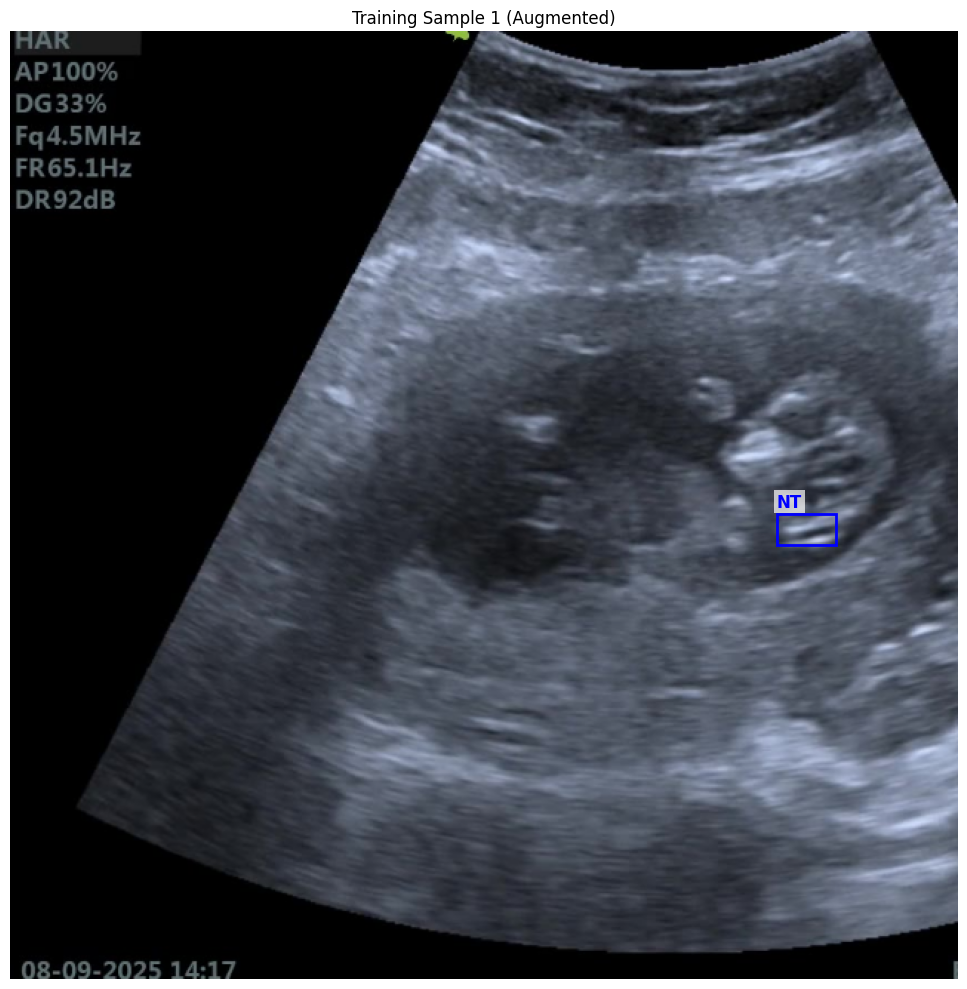

label=1
len(colors)=5
label % len(colors) =1


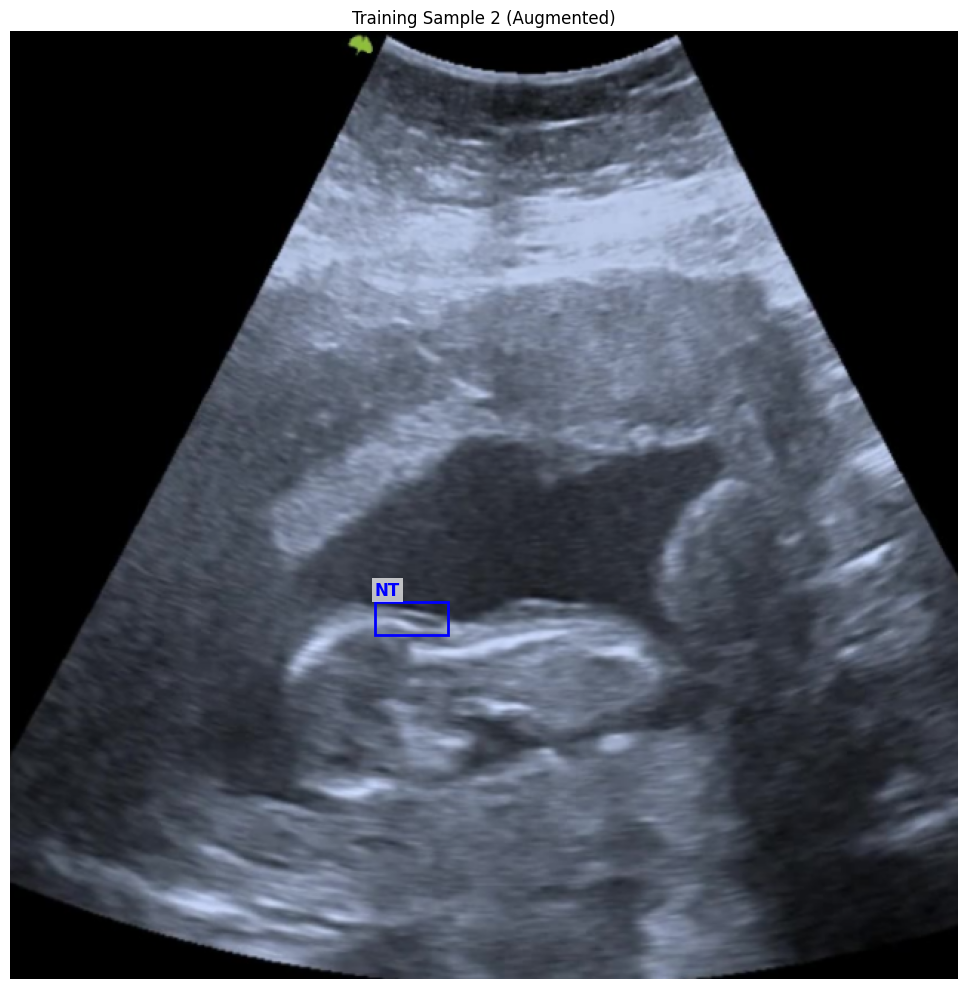

label=1
len(colors)=5
label % len(colors) =1
label=0
len(colors)=5
label % len(colors) =0


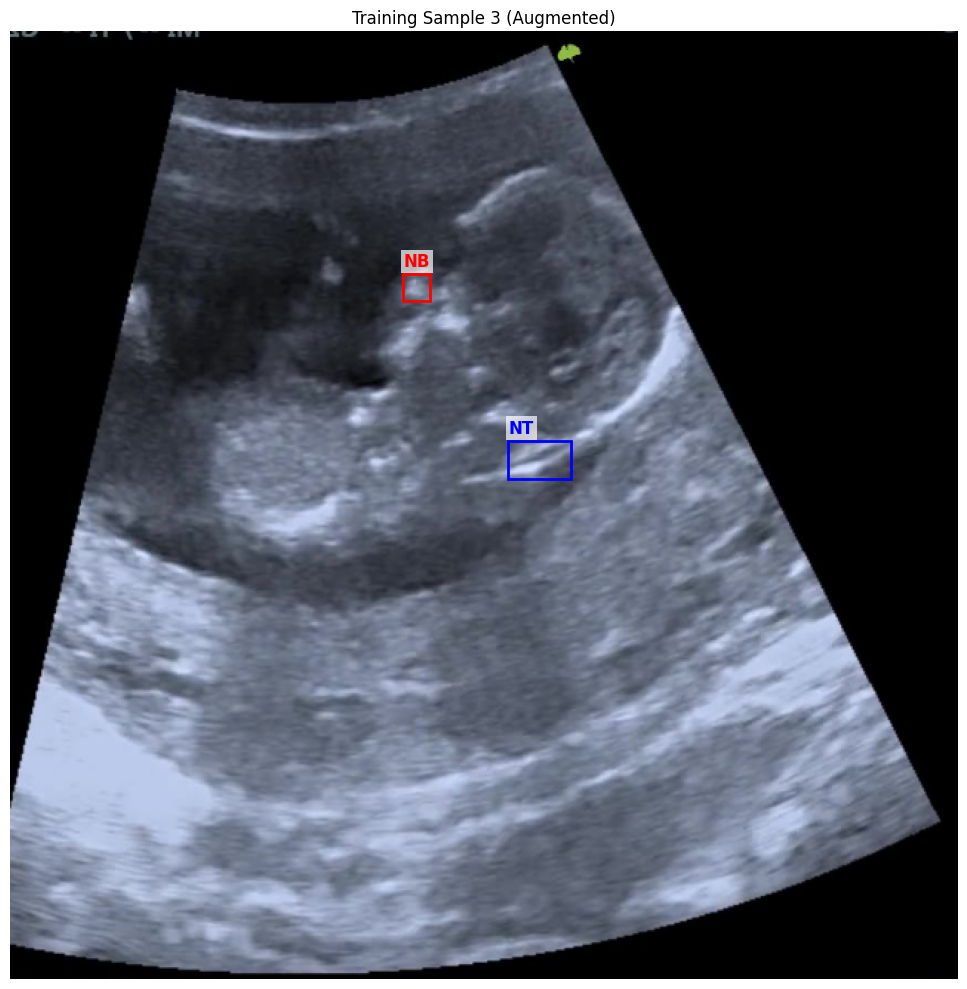


Validation samples (no augmentation):
label=1
len(colors)=5
label % len(colors) =1
label=0
len(colors)=5
label % len(colors) =0


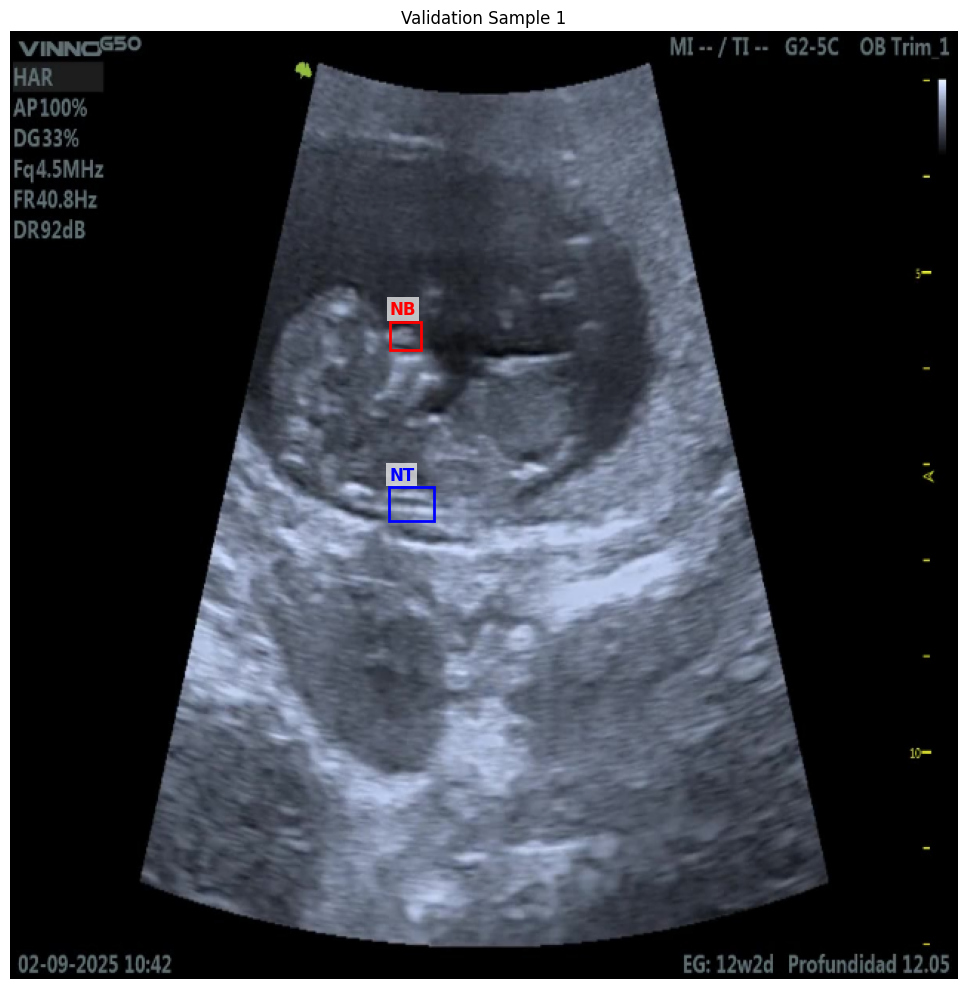

label=1
len(colors)=5
label % len(colors) =1


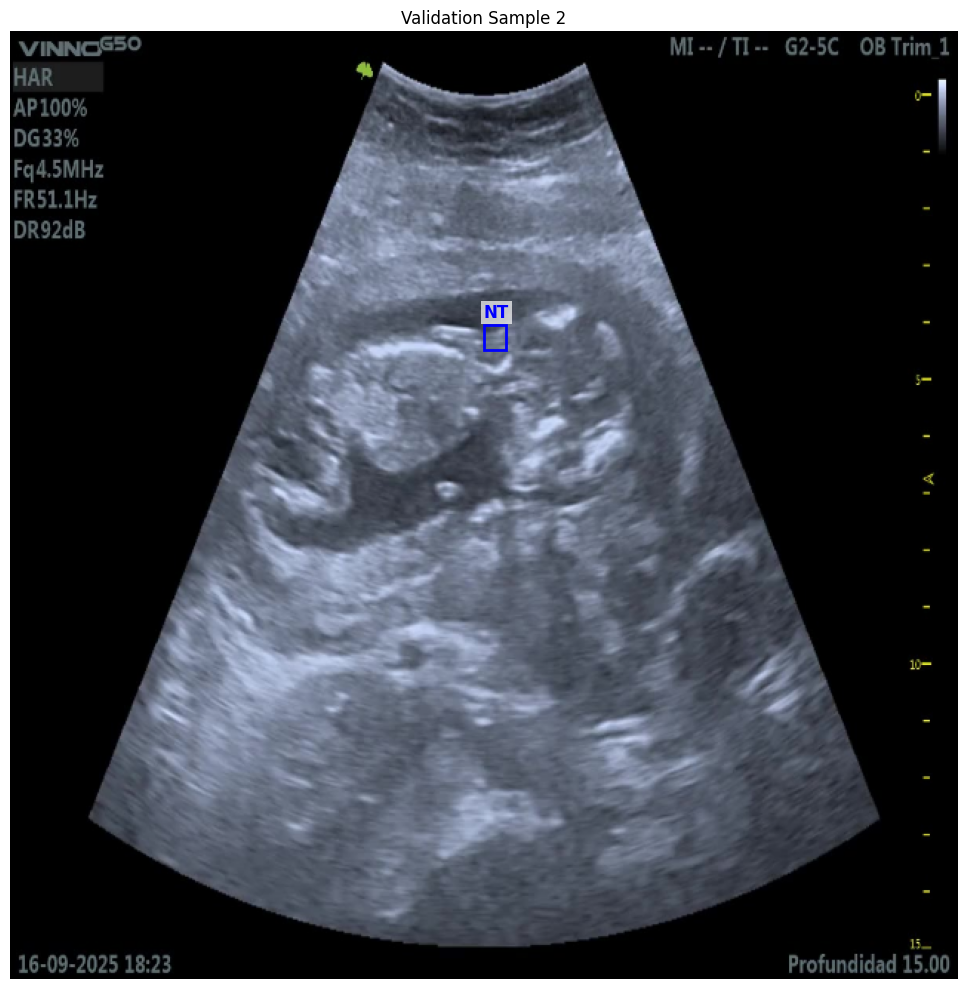

label=1
len(colors)=5
label % len(colors) =1


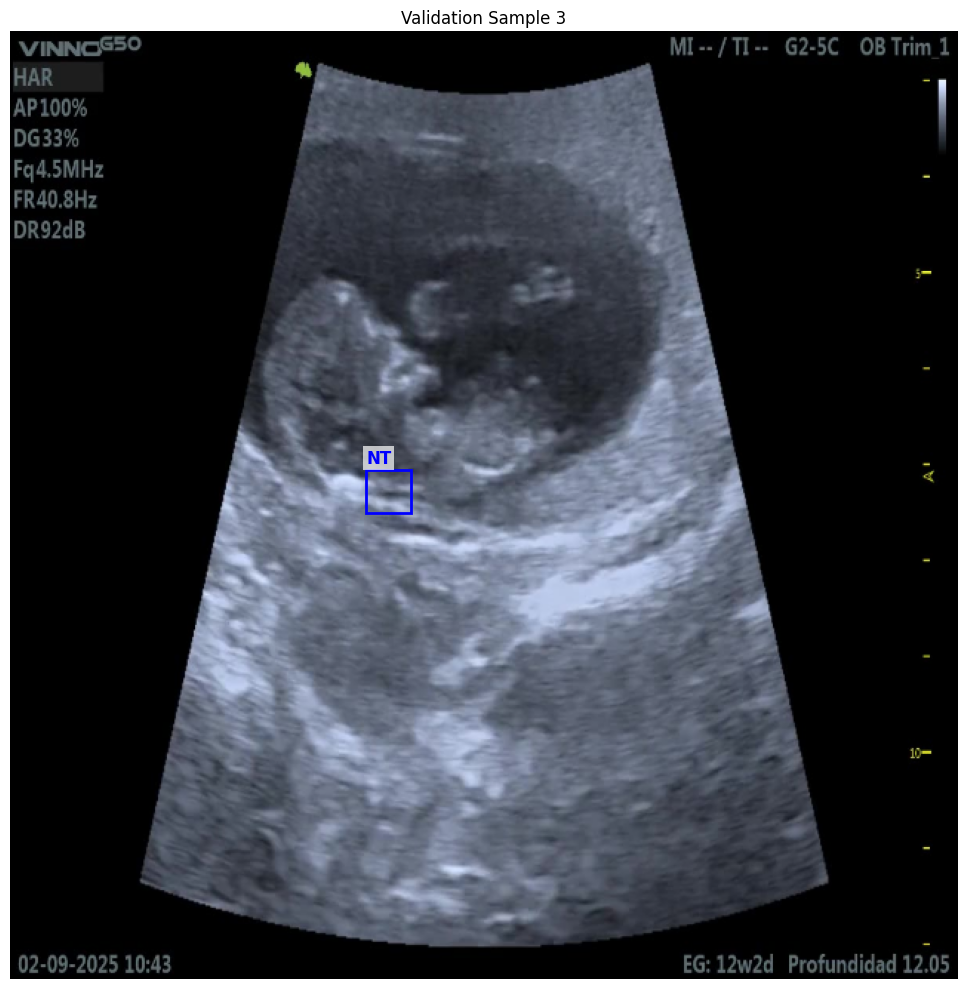

In [29]:
# Visualize a sample with augmentation
def visualize_sample(sample, title="Sample"):
    """Visualize an image with its bounding boxes"""
    import matplotlib.patches as patches

    image = sample['image']
    bboxes = sample['bboxes']
    labels = sample['labels']

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image)
    ax.set_title(title)

    # Draw bounding boxes
    colors = ['red', 'blue', 'green', 'yellow', 'purple']
    label_names = {0: 'NB', 1: 'NT'}

    for bbox, label in zip(bboxes, labels):
        x_min, y_min, x_max, y_max = bbox
        width = x_max - x_min
        height = y_max - y_min
        print(f"{label=}")
        print(f"{len(colors)=}")
        print(f"{label % len(colors) =}")

        rect = patches.Rectangle(
            (x_min, y_min), width, height,
            linewidth=2, edgecolor=colors[label % len(colors)],
            facecolor='none'
        )
        ax.add_patch(rect)

        # Add label text
        ax.text(
            x_min, y_min - 5,
            label_names[label],

            color=colors[label % len(colors)],
            fontsize=12,
            weight='bold',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
        )

    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Visualize training samples with augmentation
print("Training samples (with augmentation):")
for i in range(3):
    sample = train_dataset[i % len(train_dataset)]
    visualize_sample(sample, f"Training Sample {i% len(train_dataset) + 1} (Augmented)")

# Visualize validation samples
print("\nValidation samples (no augmentation):")
for i in range(3):
    sample = val_dataset[i]
    visualize_sample(sample, f"Validation Sample {i + 1}")


# Finetune

In [30]:
# Additional metrics functions (matching model-training.ipynb)
import torch

def box_iou(box1: torch.Tensor, box2: torch.Tensor) -> float:
    """
    Calculate IoU between two bounding boxes.
    Args:
        box1, box2: (cx, cy, w, h) in normalized [0, 1]
    Returns:
        IoU value
    """
    box1 = box1.clone()
    box2 = box2.clone()
    x1_min = float(box1[0] - box1[2] / 2)
    y1_min = float(box1[1] - box1[3] / 2)
    x1_max = float(box1[0] + box1[2] / 2)
    y1_max = float(box1[1] + box1[3] / 2)
    x2_min = float(box2[0] - box2[2] / 2)
    y2_min = float(box2[1] - box2[3] / 2)
    x2_max = float(box2[0] + box2[2] / 2)
    y2_max = float(box2[1] + box2[3] / 2)
    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)
    inter_area = max(0, inter_xmax - inter_xmin) * max(0, inter_ymax - inter_ymin)
    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)
    union = area1 + area2 - inter_area
    return inter_area / union if union > 0 else 0.0


def compute_map_per_image(
        gt_mask: torch.Tensor,
        gt_boxes: torch.Tensor,
        pred_mask: torch.Tensor,
        pred_boxes: torch.Tensor,
        iou_thresh: float = 0.5
) -> float:
    """
    Compute mAP per image.
    """
    aps = []
    for k in range(gt_mask.shape[0]):
        gt_present = gt_mask[k].item() == 1
        pred_present = pred_mask[k].item() > 0.5
        if gt_present and pred_present:
            iou = box_iou(gt_boxes[k], pred_boxes[k])
            aps.append(1.0 if iou >= iou_thresh else 0.0)
        elif not gt_present and not pred_present:
            continue  # true negative
        else:
            aps.append(0.0)  # either FN or FP
    return sum(aps) / len(aps) if aps else 0.0

In [31]:
import shutil
from pathlib import Path
from ultralytics import YOLO
import yaml
import mlflow
import mlflow.pytorch
from mlflow.tracking import MlflowClient


In [32]:
# Setup MLflow
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

print(f"MLflow Tracking URI: {MLFLOW_URI}")
print(f"MLflow Experiment: {MLFLOW_EXPERIMENT_NAME}")


MLflow Tracking URI: http://localhost:5000
MLflow Experiment: Fetal_Structures_yolo_640x640_finetuned_solimed


In [33]:
# YOLO Dataset Preparation
class YOLODatasetPreparator:
    """
    Prepares dataset for YOLO training by creating the proper directory structure
    and converting bounding boxes to YOLO format.
    """
    def __init__(self, dataset, output_dir):
        """
        Args:
            dataset: PyTorch Dataset instance (train_dataset or val_dataset)
            output_dir: Directory where YOLO format data will be saved
        """
        self.dataset = dataset
        self.output_dir = Path(output_dir)

    def prepare_split(self, split_name):
        """
        Prepare a data split (train/val) in YOLO format.

        Args:
            split_name: Name of the split ('train' or 'val')

        Returns:
            Path to the split directory
        """
        split_dir = self.output_dir / split_name
        images_dir = split_dir / 'images'
        labels_dir = split_dir / 'labels'

        # Create directories
        images_dir.mkdir(parents=True, exist_ok=True)
        labels_dir.mkdir(parents=True, exist_ok=True)

        print(f"Preparing {split_name} split with {len(self.dataset)} images...")

        for idx in range(len(self.dataset)):
            sample = self.dataset[idx]

            image = sample['image']
            bboxes = sample['bboxes']
            labels = sample['labels']
            media_id = sample['media_id']

            # Skip if no bounding boxes (after augmentation some might be filtered out)
            if len(bboxes) == 0:
                print(f"  Warning: Skipping image {media_id} (no bboxes after augmentation)")
                continue

            # Save image
            image_path = images_dir / f"{media_id}.jpg"
            import cv2
            cv2.imwrite(str(image_path), cv2.cvtColor(image, cv2.COLOR_RGB2BGR))

            # Convert bounding boxes to YOLO format and save labels
            label_path = labels_dir / f"{media_id}.txt"
            with open(label_path, 'w') as f:
                img_h, img_w = image.shape[:2]

                for bbox, label in zip(bboxes, labels):
                    x_min, y_min, x_max, y_max = bbox

                    # Convert to YOLO format (normalized center_x, center_y, width, height)
                    x_center = ((x_min + x_max) / 2) / img_w
                    y_center = ((y_min + y_max) / 2) / img_h
                    width = (x_max - x_min) / img_w
                    height = (y_max - y_min) / img_h

                    # Write: <class_id> <x_center> <y_center> <width> <height>
                    f.write(f"{label} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

            if (idx + 1) % 50 == 0:
                print(f"  Processed {idx + 1}/{len(self.dataset)} images")

        print(f"✅ {split_name} split prepared: {len(list(images_dir.glob('*.jpg')))} images")
        return split_dir

def create_yolo_config(dataset_dir, train_dataset, output_path=None):
    """
    Create YOLO dataset configuration file.

    Args:
        dataset_dir: Root directory of the YOLO dataset
        train_dataset: Training dataset to extract class information
        output_path: Path to save the config file (optional)

    Returns:
        Path to the config file
    """
    if output_path is None:
        output_path = Path(dataset_dir) / 'dataset.yaml'

    config = {
        'path': str(Path(dataset_dir).absolute()),
        'train': 'train/images',
        'val': 'val/images',
        'nc': len(train_dataset.class_to_idx),
        'names': list(train_dataset.class_to_idx.keys())
    }

    with open(output_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False)

    print(f"✅ YOLO config created at: {output_path}")
    return output_path


In [34]:
# Prepare YOLO dataset
YOLO_DATASET_DIR = os.path.join(FINETUNE_DS_DIR, 'yolo_finetuning_dataset')

# Clean up existing dataset if it exists
if os.path.exists(YOLO_DATASET_DIR):
    print(f"Removing existing dataset directory: {YOLO_DATASET_DIR}")
    shutil.rmtree(YOLO_DATASET_DIR)

# Prepare training split
train_preparator = YOLODatasetPreparator(train_dataset, YOLO_DATASET_DIR)
train_dir = train_preparator.prepare_split('train')

# Prepare validation split
val_preparator = YOLODatasetPreparator(val_dataset, YOLO_DATASET_DIR)
val_dir = val_preparator.prepare_split('val')

# Create YOLO config file
config_path = create_yolo_config(YOLO_DATASET_DIR, train_dataset)

print("\n" + "="*50)
print("📊 Dataset Preparation Complete!")
print("="*50)
print(f"Dataset directory: {YOLO_DATASET_DIR}")
print(f"Config file: {config_path}")
print(f"Training images: {len(list((Path(YOLO_DATASET_DIR) / 'train' / 'images').glob('*.jpg')))}")
print(f"Validation images: {len(list((Path(YOLO_DATASET_DIR) / 'val' / 'images').glob('*.jpg')))}")


Removing existing dataset directory: /home/gonzagrau/IamedicDrive/annotations_backups/2025-30-09/yolo_finetuning_dataset
Preparing train split with 11 images...
✅ train split prepared: 11 images
Preparing val split with 5 images...
✅ val split prepared: 5 images
✅ YOLO config created at: /home/gonzagrau/IamedicDrive/annotations_backups/2025-30-09/yolo_finetuning_dataset/dataset.yaml

📊 Dataset Preparation Complete!
Dataset directory: /home/gonzagrau/IamedicDrive/annotations_backups/2025-30-09/yolo_finetuning_dataset
Config file: /home/gonzagrau/IamedicDrive/annotations_backups/2025-30-09/yolo_finetuning_dataset/dataset.yaml
Training images: 11
Validation images: 5


In [35]:
# Load the pretrained model from BEST_MODEL_PATH
print(f"\n{'='*50}")
print(f"🚀 Loading Pretrained Model for Finetuning")
print(f"{'='*50}")
print(f"Model path: {BEST_MODEL_PATH}")

model = YOLO(BEST_MODEL_PATH)

print(f"✅ Model loaded successfully!")
print(f"Model summary:")
model.info()



🚀 Loading Pretrained Model for Finetuning
Model path: checkpoints/yolo_fetal_structures_20250923_223741/weights/best.pt
✅ Model loaded successfully!
Model summary:
Model summary: 129 layers, 3,011,238 parameters, 0 gradients, 8.2 GFLOPs
✅ Model loaded successfully!
Model summary:
Model summary: 129 layers, 3,011,238 parameters, 0 gradients, 8.2 GFLOPs


(129, 3011238, 0, 8.1952256)

In [36]:
# Configure training arguments
import time
timestamp = time.strftime("%Y%m%d_%H%M%S")

# Disable YOLO's built-in MLflow integration (we're doing manual tracking)
from ultralytics import settings
settings.update({'mlflow': False})
print("✓ YOLO's built-in MLflow integration disabled (using manual tracking)")

yolo_train_args = {
    'data': str(config_path),
    'epochs': NUM_EPOCHS,
    'imgsz': max(TARGET_HEIGHT, TARGET_WIDTH),
    'batch': BATCH_SIZE,
    'lr0': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'patience': EARLY_STOPPING_PATIENCE,
    'save': True,
    'save_period': 10,  # Save checkpoint every 10 epochs
    'project': 'runs/finetune',
    'name': f'yolo_finetuned_{timestamp}',
    'exist_ok': False,
    'pretrained': True,
    'optimizer': 'AdamW',
    'verbose': True,
    'seed': 0,
    'deterministic': True,
    'single_cls': False,
    'rect': False,
    'cos_lr': True,
    'close_mosaic': 10,  # Disable mosaic augmentation in last 10 epochs
    'resume': False,
    'amp': True,  # Automatic Mixed Precision
    'fraction': 1.0,
    'profile': False,
    'freeze': None,  # No layers frozen (full finetuning)
    'multi_scale': False,
    'overlap_mask': True,
    'mask_ratio': 4,
    'dropout': 0.2,
    'val': True,
    'plots': True,
    'workers': 8,
}

print(f"\n{'='*50}")
print(f"⚙️  Training Configuration")
print(f"{'='*50}")
print(f"   📁 Dataset: {yolo_train_args['data']}")
print(f"   🖼️  Image size: {yolo_train_args['imgsz']}px")
print(f"   🔄 Epochs: {yolo_train_args['epochs']}")
print(f"   📦 Batch size: {yolo_train_args['batch']}")
print(f"   📈 Learning rate: {yolo_train_args['lr0']}")
print(f"   ⏱️  Patience: {yolo_train_args['patience']}")
print(f"   💾 Output: {yolo_train_args['project']}/{yolo_train_args['name']}")
print(f"   🔧 Optimizer: {yolo_train_args['optimizer']}")
print(f"   ❄️  Frozen layers: {yolo_train_args['freeze']}")


✓ YOLO's built-in MLflow integration disabled (using manual tracking)

⚙️  Training Configuration
   📁 Dataset: /home/gonzagrau/IamedicDrive/annotations_backups/2025-30-09/yolo_finetuning_dataset/dataset.yaml
   🖼️  Image size: 640px
   🔄 Epochs: 1000
   📦 Batch size: 32
   📈 Learning rate: 0.01
   ⏱️  Patience: 20
   💾 Output: runs/finetune/yolo_finetuned_20251009_003919
   🔧 Optimizer: AdamW
   ❄️  Frozen layers: None


In [37]:
# Start finetuning with MLflow tracking
print(f"\n{'='*50}")
print(f"🎯 Starting YOLO Finetuning with MLflow Tracking")
print(f"{'='*50}\n")

# Start MLflow run
with mlflow.start_run(run_name=f"finetune_{timestamp}") as run:
    run_id = run.info.run_id
    print(f"📊 MLflow Run ID: {run_id}")

    # Log parameters
    mlflow.log_params({
        'model_name': MODEL_NAME,
        'dataset_version': DATASET_VERSION,
        'pretrained_model': BEST_MODEL_PATH,
        'target_height': TARGET_HEIGHT,
        'target_width': TARGET_WIDTH,
        'num_epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'optimizer': yolo_train_args['optimizer'],
        'train_samples': len(train_dataset),
        'val_samples': len(val_dataset),
        'num_classes': len(train_dataset.class_to_idx),
        'classes': str(list(train_dataset.class_to_idx.keys())),
        'augmentation_enabled': True,
        'freeze_layers': yolo_train_args['freeze'],
        'cos_lr': yolo_train_args['cos_lr'],
        'amp': yolo_train_args['amp'],
    })

    # Log dataset info
    mlflow.log_params({
        'train_annotations': len(train_annotations_df),
        'val_annotations': len(val_annotations_df),
        'total_annotations': len(annotations_df),
        'train_val_split': f"{train_size/total_size:.2f}/{val_size/total_size:.2f}",
    })

    # Log augmentation config
    mlflow.log_dict({
        'horizontal_flip': {'p': 0.5},
        'vertical_flip': {'p': 0.2},
        'affine': {
            'scale': (0.98, 1.08),
            'translate_percent': {'x': (-0.02, 0.02), 'y': (-0.02, 0.02)},
            'rotate': (-3, 3),
            'shear': (-0.5, 0.5),
            'p': 0.3
        },
        'optical_distortion': {'distort_limit': 0.05, 'p': 0.1},
        'grid_distortion': {'distort_limit': 0.05, 'p': 0.1},
        'elastic_transform': {'alpha': 0.2, 'sigma': 5, 'p': 0.05},
        'coarse_dropout': {
            'num_holes_range': (1, 1),
            'hole_height_range': (1, 6),
            'hole_width_range': (1, 6),
            'fill': 'inpaint_ns',
            'p': 0.1
        }
    }, 'augmentation_config.json')

    try:
        # Train the model
        results = model.train(**yolo_train_args)
        
        # Log all training results (including train/val loss and other metrics)
        if hasattr(results, 'results_dict'):
            for key, value in results.results_dict.items():
                if isinstance(value, (int, float)):
                    mlflow.log_metric(key, value)

        print(f"\n{'='*50}")
        print(f"✅ Finetuning Complete!")
        print(f"{'='*50}")

        # Get the training directory
        training_dir = os.path.join(yolo_train_args['project'], yolo_train_args['name'])
        best_model_path = os.path.join(training_dir, 'weights', 'best.pt')
        last_model_path = os.path.join(training_dir, 'weights', 'last.pt')

        print(f"📁 Training directory: {training_dir}")
        print(f"🏆 Best model: {best_model_path}")
        print(f"💾 Last model: {last_model_path}")

        # Load the best model and validate
        print(f"\n{'='*50}")
        print(f"📊 Validating Best Model")
        print(f"{'='*50}")

        best_model = YOLO(best_model_path)
        val_results = best_model.val(data=str(config_path))

        # Log metrics
        metrics = {
            'final_mAP50': val_results.box.map50,
            'final_mAP50_95': val_results.box.map,
            'final_precision': val_results.box.mp,
            'final_recall': val_results.box.mr,
        }
        
        # Add box IoU metrics if available 
        if hasattr(val_results, 'box') and hasattr(val_results.box, 'iou'):
            if val_results.box.iou is not None:
                if isinstance(val_results.box.iou, (list, tuple, torch.Tensor)):
                    metrics['avg_box_iou'] = float(torch.mean(torch.tensor(val_results.box.iou)) if torch.is_tensor(val_results.box.iou) else sum(val_results.box.iou) / len(val_results.box.iou))
                else:
                    metrics['avg_box_iou'] = float(val_results.box.iou)
        
        # Log per-class metrics if available
        if hasattr(val_results.box, 'maps') and val_results.box.maps is not None:
            for idx, class_name in enumerate(train_dataset.class_to_idx.keys()):
                if idx < len(val_results.box.maps):
                    metrics[f'mAP50_95_{class_name}'] = val_results.box.maps[idx]

        if hasattr(val_results.box, 'ap50') and val_results.box.ap50 is not None:
            for idx, class_name in enumerate(train_dataset.class_to_idx.keys()):
                if idx < len(val_results.box.ap50):
                    metrics[f'mAP50_{class_name}'] = val_results.box.ap50[idx]

        # Sanitize metric names to remove invalid characters for MLflow
        for key in metrics.keys():
            safe_key = key.replace('(', '').replace(')', '').replace(',', '').replace(' ', '_').replace('/', '_')
            mlflow.log_metric(safe_key, metrics[key])

        print(f"\n{'='*50}")
        print(f"📈 Validation Results")
        print(f"{'='*50}")
        print(f"   mAP50: {val_results.box.map50:.4f}")
        print(f"   mAP50-95: {val_results.box.map:.4f}")
        print(f"   Precision: {val_results.box.mp:.4f}")
        print(f"   Recall: {val_results.box.mr:.4f}")

        # Log training artifacts
        print(f"\n📦 Logging artifacts to MLflow...")

        # Log the best model weights
        mlflow.log_artifact(best_model_path, "weights")
        mlflow.log_artifact(last_model_path, "weights")

        # Log training plots and results
        results_csv = os.path.join(training_dir, 'results.csv')
        if os.path.exists(results_csv):
            mlflow.log_artifact(results_csv, "training_results")

        # Log plots if they exist
        plot_files = [
            'results.png',
            'confusion_matrix.png',
            'confusion_matrix_normalized.png',
            'BoxF1_curve.png',
            'BoxP_curve.png',
            'BoxPR_curve.png',
            'BoxR_curve.png',
        ]

        for plot_file in plot_files:
            plot_path = os.path.join(training_dir, plot_file)
            if os.path.exists(plot_path):
                mlflow.log_artifact(plot_path, "plots")

        # Log validation batch predictions
        for i in range(3):
            val_labels = os.path.join(training_dir, f'val_batch{i}_labels.jpg')
            val_pred = os.path.join(training_dir, f'val_batch{i}_pred.jpg')
            if os.path.exists(val_labels):
                mlflow.log_artifact(val_labels, "validation_examples")
            if os.path.exists(val_pred):
                mlflow.log_artifact(val_pred, "validation_examples")

        # Log dataset config
        mlflow.log_artifact(str(config_path), "config")

        # Log args.yaml
        args_yaml = os.path.join(training_dir, 'args.yaml')
        if os.path.exists(args_yaml):
            mlflow.log_artifact(args_yaml, "config")

        # Register model in MLflow Model Registry
        print(f"\n🏷️  Registering model in MLflow Model Registry...")

        # Log model as PyTorch model
        mlflow.pytorch.log_model(
            pytorch_model=best_model.model,
            artifact_path="model",
            registered_model_name=MODEL_NAME,
        )

        # Also log the YOLO .pt file
        mlflow.log_artifact(best_model_path, "yolo_model")

        # Add model tags
        client = MlflowClient()
        client.set_tag(run_id, "model_type", "YOLOv8")
        client.set_tag(run_id, "task", "object_detection")
        client.set_tag(run_id, "dataset", "fetal_structures_solimed")
        client.set_tag(run_id, "finetuned", "true")
        client.set_tag(run_id, "user", MLFLOW_USER)

        print(f"✅ Model registered: {MODEL_NAME}")
        print(f"📊 MLflow Run ID: {run_id}")
        print(f"🔗 View in MLflow UI: {MLFLOW_URI}")

    except Exception as e:
        print(f"\n❌ Error during training: {e}")
        mlflow.log_param("training_status", "failed")
        mlflow.log_param("error_message", str(e))
        raise

print(f"\n{'='*50}")
print(f"🎉 Finetuning and MLflow Logging Complete!")
print(f"{'='*50}")



🎯 Starting YOLO Finetuning with MLflow Tracking

📊 MLflow Run ID: 940916d0783a497f82ecbe2382e30d8e
New https://pypi.org/project/ultralytics/8.3.207 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 11918MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/gonzagrau/IamedicDrive/annotations_backups/2025-30-09/yolo_finetuning_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, epochs=1000, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_widt

RestException: INVALID_PARAMETER_VALUE: Invalid value "metrics/precision(B)" for parameter 'name' supplied: Names may only contain alphanumerics, underscores (_), dashes (-), periods (.), spaces ( ), colon(:) and slashes (/).